In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx

ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
width=4
gap = 2
num_iters = 50

In [75]:
coordrl = rlp.io.read_trajectory("rrsg/rrsg-radial.h5")
kspa = rlp.io.read_data("rrsg/rrsg-radial.h5")
kspace = np.asarray(kspa)
kspace = kspace[0, 0] 
ksprl = np.moveaxis(kspace, -1, 0)

## Goal of the notebook

### Integrate riesling into sigpy pipeline

1. Start with NUFFT inverse

In [76]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp = ksp, coord=coord, n_missing=0, undersampling_factor=1)
zte_radial_kspacerl, zte_radial_coordsrl = asm.generate_zte_data_OLD(ksp = ksprl, coord=coordrl, n_missing=0, undersampling_factor=1)

- get the above file format into something that riseling can read

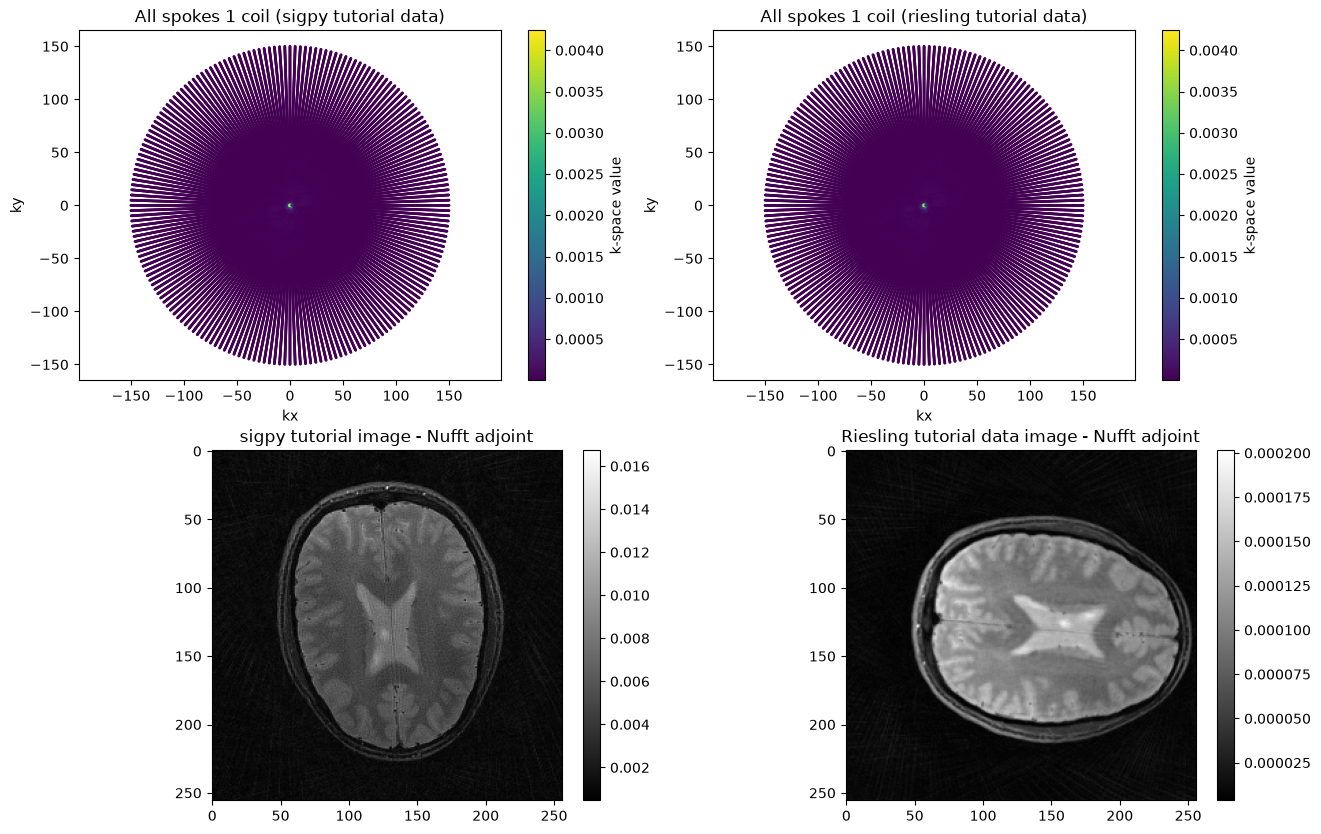

In [103]:
### Original Image
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_orig_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords, oshape=(12,256,256))
zte_orig_image = np.sum(np.abs(zte_orig_grid)**2, axis=0)**0.5

dcfrl = np.sqrt(zte_radial_coordsrl[..., 0]**2 + zte_radial_coordsrl[..., 1]**2)
zte_orig_gridrl = sp.nufft_adjoint(zte_radial_kspacerl * dcf, zte_radial_coordsrl, oshape=(12,256,256))
zte_orig_imagerl = np.sum(np.abs(zte_orig_gridrl)**2, axis=0)**0.5

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

all_coordsrl = zte_radial_coordsrl.reshape(-1,2)
all_kspacerl = zte_radial_kspacerl[0].reshape(-1)


fig, ax = plt.subplots(2, 2, figsize=(15, 10))
im0 = ax[0, 0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0, 0].set_title('All spokes 1 coil (sigpy tutorial data)')
ax[0, 0].set_xlabel('kx')
ax[0, 0].set_ylabel('ky')
ax[0, 0].axis('equal')
fig.colorbar(im0, ax=ax[0,0], label='k-space value')

im1 = ax[0, 1].scatter(all_coordsrl[:, 0], all_coordsrl[:, 1], c=np.abs(all_kspacerl), s=1)
ax[0, 1].set_title('All spokes 1 coil (riesling tutorial data)')
ax[0, 1].set_xlabel('kx')
ax[0, 1].set_ylabel('ky')
ax[0, 1].axis('equal')
fig.colorbar(im1, ax=ax[0,1], label='k-space value')

im0 = ax[1, 0].imshow(zte_orig_image, cmap='gray')
ax[1, 0].set_title('sigpy tutorial image - Nufft adjoint')
plt.colorbar(im0, ax=ax[1, 0], fraction=0.046, pad=0.04)

im1 = ax[1, 1].imshow(im_rss_recon, cmap='gray')
ax[1, 1].set_title('Riesling tutorial data image - Nufft adjoint')
plt.colorbar(im1, ax=ax[1, 1], fraction=0.046, pad=0.04)

plt.show()

[17:10:42] [Traj  ] Discarded 3512 points (7.15%) outside matrix


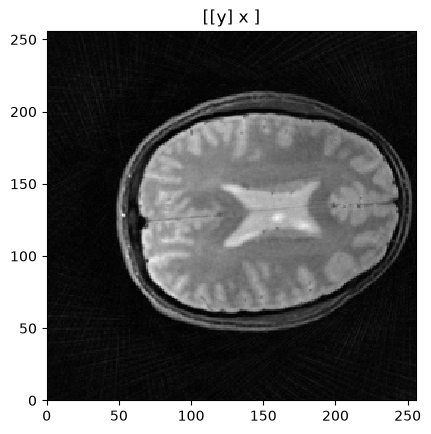

In [102]:
!riesling op-nufft2 {rpre}.h5 {rpre}-nufft.h5
rlp.plot.planes(f'{rpre}-nufft.h5', title='NUFFT')

x = rlp.io.read_data(f"{rpre}-nufft.h5")

adjointed = np.asarray(x[0,:,0,0])
adjointed.shape
im_rss_recon = np.sum(np.abs(adjointed)**2, axis=0)**0.5
pl.ImagePlot(im_rss_recon)

In [68]:
I1 = sp.nufft_adjoint(zte_radial_kspace*dcf, zte_radial_coords)
I2 = sp.nufft_adjoint(zte_radial_kspacerl*dcfrl, zte_radial_coordsrl)

img1 = np.sqrt((np.abs(I1)**2).sum(0))   # (256, 256) real
img2 = np.sqrt((np.abs(I2)**2).sum(0))

F1, F2 = np.fft.fft2(img1), np.fft.fft2(img2)
cross = F1 * np.conj(F2)
cross /= np.abs(cross) + 1e-12
corr = np.fft.fftshift(np.abs(np.fft.ifft2(cross)))

dy, dx = np.unravel_index(np.argmax(corr), corr.shape)
dy -= corr.shape[0] // 2
dx -= corr.shape[1] // 2
print(f"shift (dy, dx) = ({dy}, {dx}) px")

shift (dy, dx) = (-30, 0) px


residual / signal: 0.03736916213152167


Text(0.5, 1.0, 'residual')

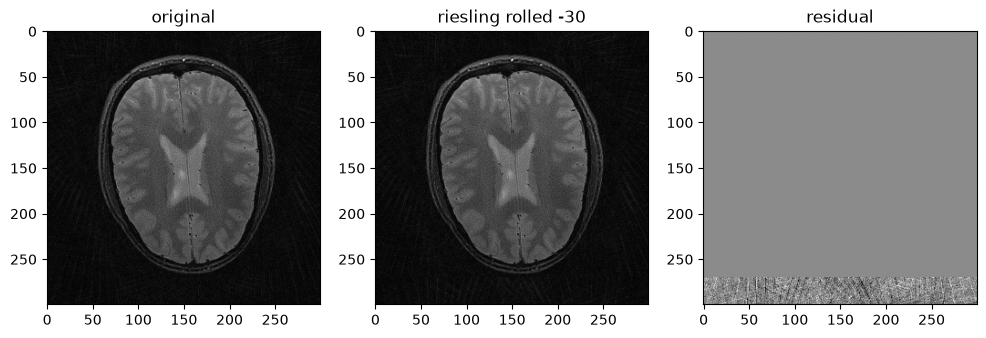

In [ ]:
img1 = np.sqrt((np.abs(I1)**2).sum(0))
img2 = np.sqrt((np.abs(I2)**2).sum(0))

aligned = np.roll(img2, -30, axis=0)
resid = img1 - aligned

print('residual / signal:', np.linalg.norm(resid) / np.linalg.norm(img1))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img1, cmap='gray');    ax[0].set_title('original')
ax[1].imshow(aligned, cmap='gray'); ax[1].set_title('riesling rolled -30')
ax[2].imshow(resid, cmap='gray');   ax[2].set_title('residual')